<a href="https://colab.research.google.com/github/Stependiaa/Project_soroki/blob/main/scripts/Lect05_example_OSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Пример для ДЗ №4 (Практическая работа №2): <br> работа с векторными данными на примере OSM

In [2]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.0 MB/s eta 0:00:00


In [3]:
import osmnx as ox
import numpy as np
from matplotlib import pyplot as plt
import geopandas as gpd

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300


<Axes: >

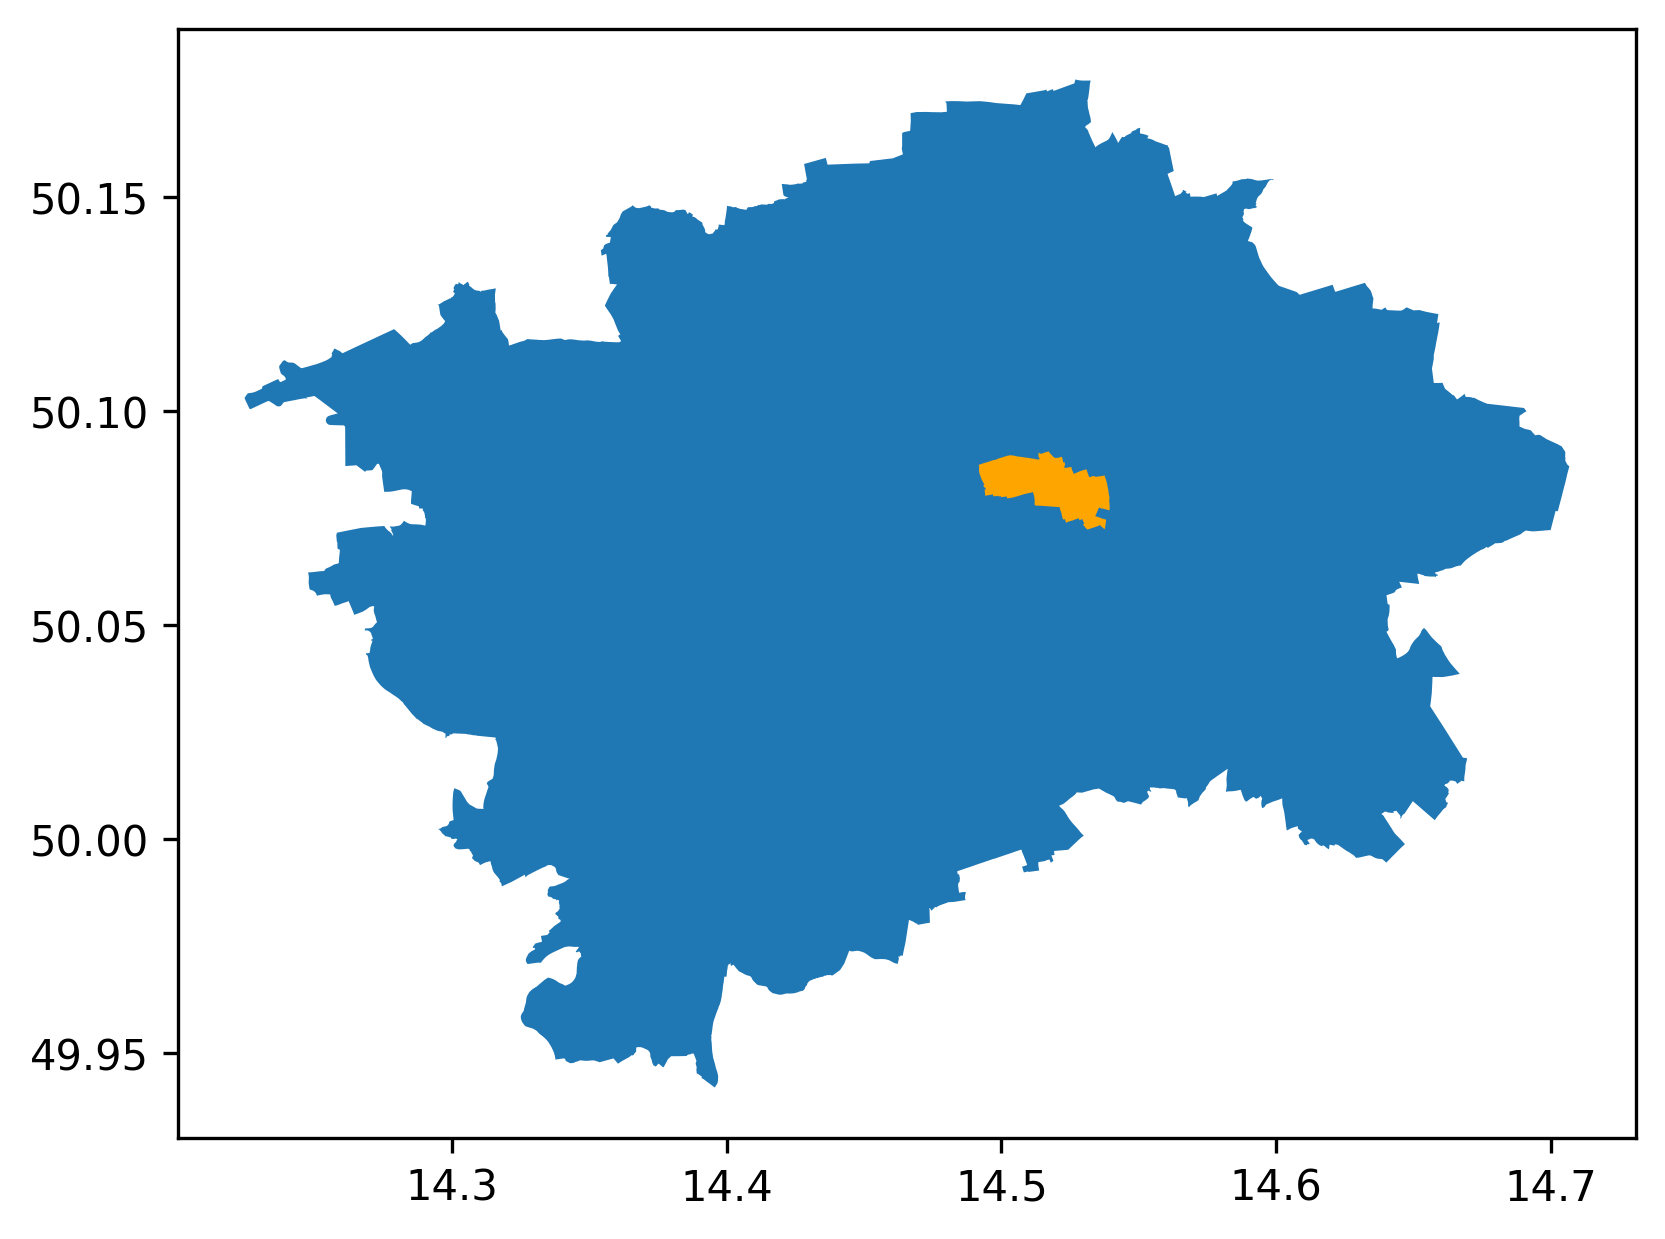

In [13]:
place_name = "Prague, CZ"
area0 = ox.geocode_to_gdf(place_name)
ax = area0.plot()

# place_name1 = "Prague, Czech Republic, CZ"
place_name1 = "MALESICE, Prague, Czech Republic"

area = ox.geocode_to_gdf(place_name1)
area.plot(ax = ax, color = 'orange')

In [14]:
area

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((14.49167 50.08734, 14.49181 50.08711...",14.491666,50.072241,14.539414,50.090562,426055589,relation,434138,50.082955,14.512095,boundary,administrative,20,0.450127,suburb,Malešice,"Malešice, SO Praha 10, obvod Praha 10, Prague,..."


In [15]:
tags = {'building': True}

# lons = area.geometry.exterior[0].xy[0]
# lats = area.geometry.exterior[0].xy[1]
# area = Polygon(list(zip(lons, lats)))

buildings = ox.features_from_polygon(area.geometry[0], tags)
buildings.shape

(1338, 76)

In [16]:
buildings['building:levels_float'] = buildings['building:levels'].astype(float)
buildings['area'] = buildings['geometry'].area

/tmp/ipykernel_899/2306012998.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings['area'] = buildings['geometry'].area


/tmp/ipykernel_899/932564241.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings[buildings['geometry'].area > 0].plot(ax = ax, legend=True, facecolor = 'gray')
/tmp/ipykernel_899/932564241.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings[buildings['geometry'].area > 0].plot(ax = ax, column = 'building:levels_float', legend=True)


<Axes: >

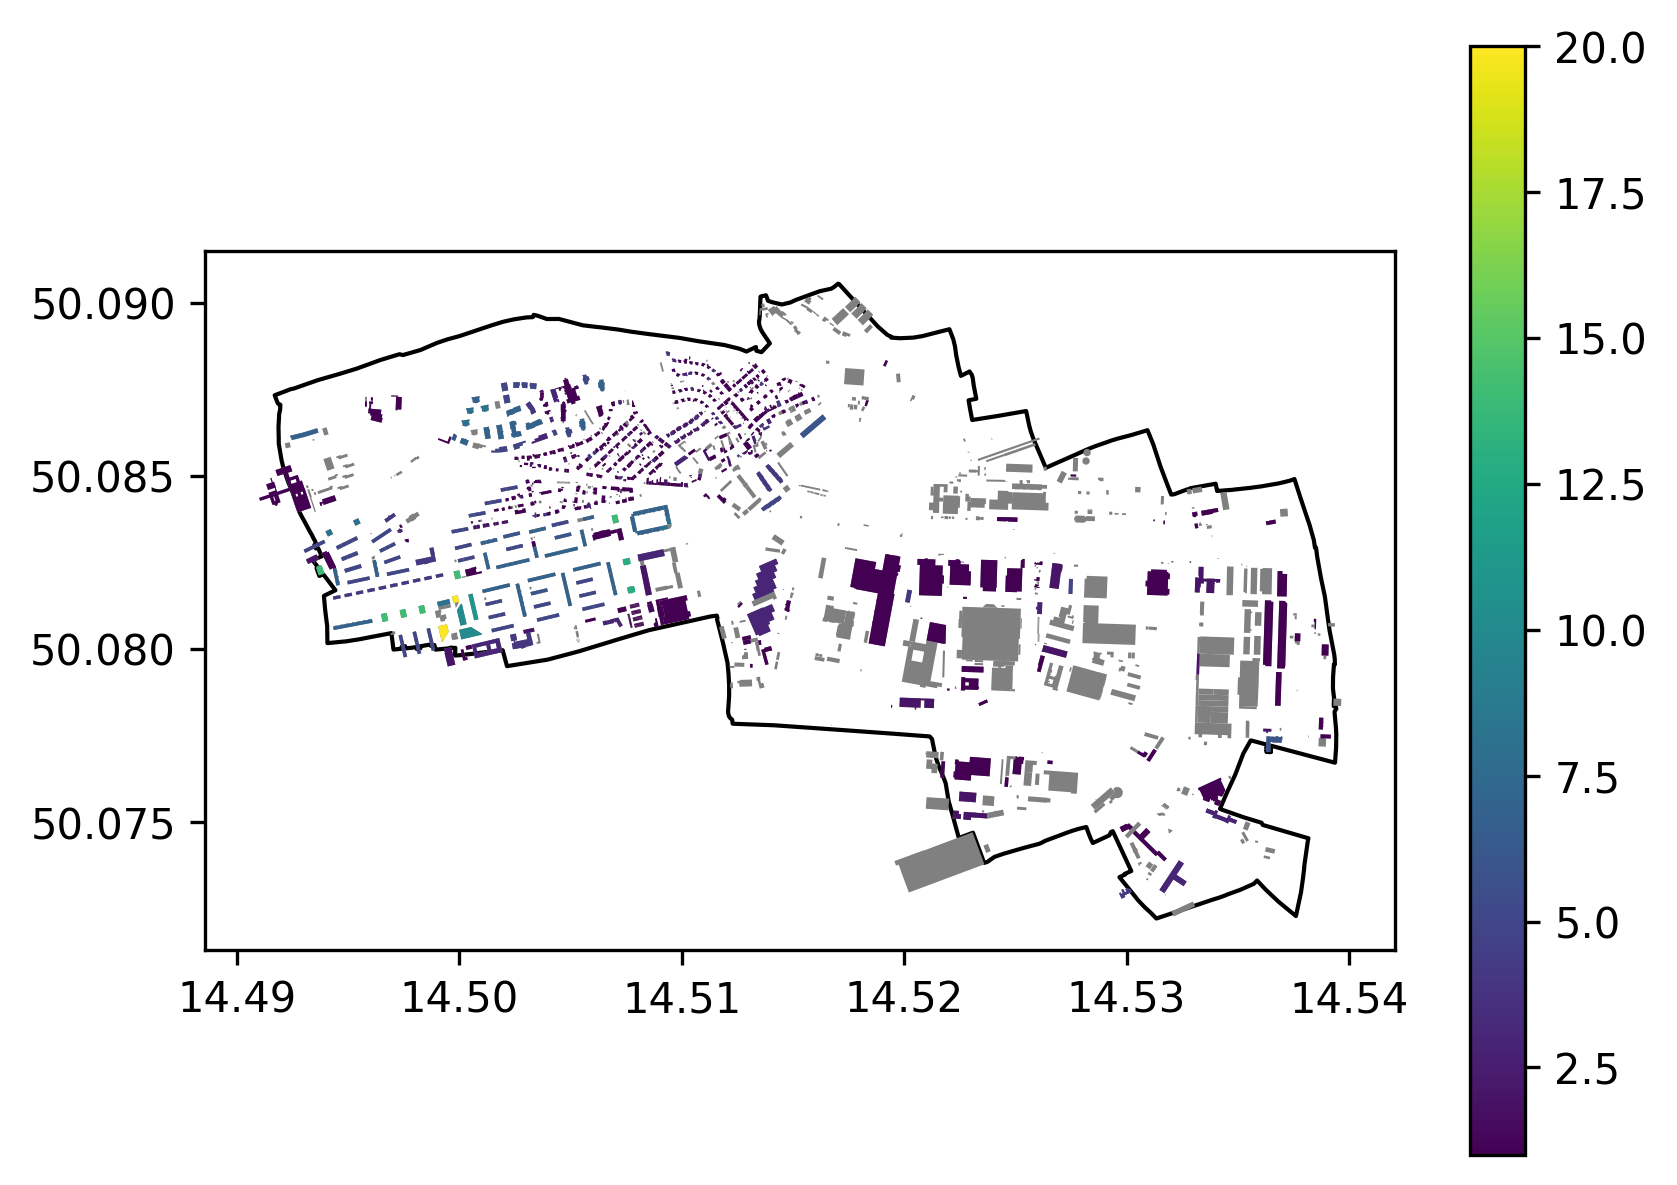

In [17]:
ax = area.plot(facecolor = [0, 0, 0, 0], edgecolor = 'black')

#buildings.plot(ax = ax, column = 'building:levels_float', legend=True)
buildings[buildings['geometry'].area > 0].plot(ax = ax, legend=True, facecolor = 'gray')

buildings[buildings['geometry'].area > 0].plot(ax = ax, column = 'building:levels_float', legend=True)


In [41]:
print(round(buildings['building:levels_float'].isnull().sum()*100/len(buildings), 3), '%  зданий без этажности')

41.629 %  зданий без этажности
